# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

In [16]:
import pandas as pd


df = pd.read_csv("./data/airbnb_hw.csv")


# raw Price column first


print(df['Price'].head(20))
print(type(df['Price'][0]))


# Price is read as a string or object, prices over 999 have commas
# Pandas is not able to convert those numbers (higher than 999)
# take commas out, convert to number


price = df['Price'].astype(str)
# make sure everything is a string


price = price.str.replace(",","")
# removes commas in the thousands place that causes issues


price = pd.to_numeric(price, errors='coerce')
# convert to float


df['Price'] = price


print(df['Price'].head(20))
print(df['Price'].describe())


# count of missing values
print("Missing values in Price:", df['Price'].isnull().sum())

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: str
<class 'str'>
0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: int64
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
Missing values in Price: 0


The price was read in as a string column, not a number - pandas guessed the "object" dtype because of the commas. In addition, any price that was over 1000 did have a comma in the thousands place as a separator. pd.to_numeric messes up reading that comma, so with direct conversion there would be an error or reslt in a NaN result. I fixed it by taking out commas with .str.replace",","" before conversion. Afterwards, I used errors='coerce' in pd.to_numeric so that any leftovers with weird values would become NaN instead of not running. As a result, when I ran the code, it came out to be 0 missing values.

The price span is between $10 and $10,000, while the median is at $125 and the mean at $164. The difference between the median and the mean clearly indicates that the data has a right-skewed distribution, as well as containing outliers. There are also quite a few prices ending with zeros, which are probably typos.


In [17]:
import pandas as pd
 
force_data = pd.read_csv("./data/mn_police_use_of_force.csv")
print(force_data.shape)
print(force_data.columns.tolist())
 
print(force_data['subject_injury'].unique())
print(force_data['subject_injury'].value_counts(dropna=False))
force_data['subject_injury'] = force_data['subject_injury'].fillna("Missing")
 
print(force_data['subject_injury'].value_counts())
 
missing = 0
total = 0

for value in force_data['subject_injury']:
    total += 1
    if value == "Missing":
        missing += 1
 
# checking my loop actually counted everything right
print(total == len(force_data))
print(total, len(force_data))
 
prop_missing = missing / total
print("Proportion missing:", prop_missing)
 
table = pd.crosstab(force_data['force_type'], force_data['subject_injury'])
print(table)
 
# do this again but as percentages so its easier to compare across force types
table_percent = pd.crosstab(force_data['force_type'], force_data['subject_injury'], normalize='index')
print(table_percent)
print(force_data.isnull().sum())

# Yes, there are patterns - missingness varies by force type --> Bodily Force accounts for 72% of all missing values
# while more severe types like Police K9 Bite and Gun Point Display are better written down.
# Injury status appears more consistently recorded for the severe types
# lower-visibility force is often skipped over, and severe ones more documented

# Bodily Force has the most missing rows in raw count, appro. 72% of all missing, b/c it's the most common force type overall
# Bodily Force's actual missing rate --> it has more incidents total

(12925, 13)
['response_datetime', 'problem', 'is_911_call', 'primary_offense', 'subject_injury', 'force_type', 'force_type_action', 'race', 'sex', 'age', 'type_resistance', 'precinct', 'neighborhood']
<StringArray>
[nan, 'No', 'Yes']
Length: 3, dtype: str
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
subject_injury
Missing    9848
Yes        1631
No         1446
Name: count, dtype: int64
True
12925 12925
Proportion missing: 0.7619342359767892
subject_injury               Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique     

For cleaning, I relabeled blank subject_injury values as "Missing" rather than assuming they meant "No" - treating unrecorded data as "no injury" would bias the results.

Missing around 76% rows.

This is a concern because only a small percentage (24%) of cases were recorded. These injury-rate estimate is based on a small, likely non-representative subset.

The pattern is dependent on the force_type. There were 100% missing for Maximal Restraint Technique and Less Lethal. However, there were around 89% missing for Chemical Irritant, but only around 26% missing for Gun Point Display. This suggests the data isn't missing at random, so injury-rate comparisons across force types should be looked at in-depth.

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I have not used generative AI on this assignment.

**Student(s):** Vivian Le

**Date:** 9/8/2026

['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
(7117, 23)
(7117, 21)
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']
count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64
5.0 2026.0
Year
1941.0     27
1942.0     41
1943.0     28
1944.0     31
1945.0     16
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Length: 86, dtype: int64


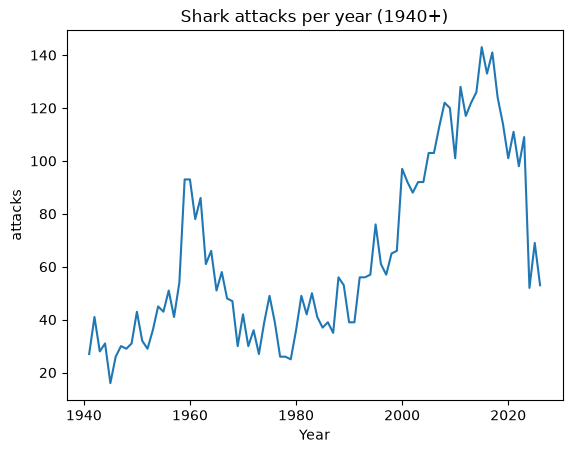

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


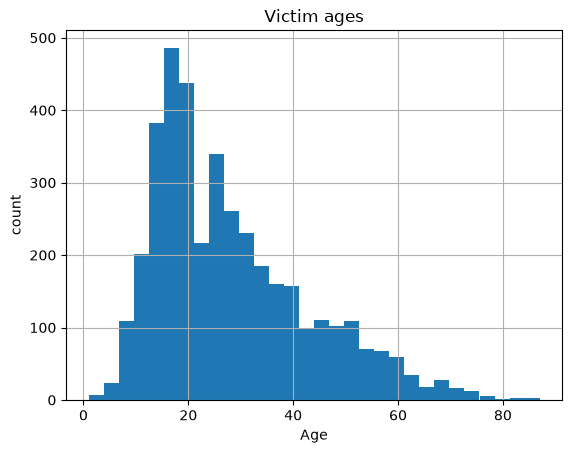

Sex
M        5594
F         803
NaN       570
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64
Sex
M      5603
F       805
NaN     578
Name: count, dtype: int64
Sex
M    0.874376
F    0.125624
Name: proportion, dtype: float64
proportion male: 0.8743757802746567
Type
Unprovoked             5150
Provoked                640
Invalid                 549
Watercraft              353
Sea Disaster            236
Questionable             27
NaN                      16
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type
Unprovoked    5152
Unknown       1192
Provoked       642
Name: count, dtype: int64
proportion unprovoked: 0.7374749498997996


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
 
# xls file, not csv, so use read_excel here
sharks = pd.read_excel("./data/GSAF5.xls")
 
print(sharks.columns.tolist())
print(sharks.shape)
 
# get rid of columns that are empty
sharks = sharks.dropna(axis=1, how='all')
 
# a few "empty" columns had one random  value in them, typed "stopped here", essentionally all missing too
min_non_null = int(0.01 * len(sharks))
sharks = sharks.dropna(axis=1, thresh=min_non_null)
 
print(sharks.shape)
print(sharks.columns.tolist())
 
# Year cleaning
# theres some 0s and other information, going to coerce it
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce')
 
print(sharks['Year'].describe())
sharks = sharks[sharks['Year'] > 0]
year_max = sharks['Year'].max()
year_min = sharks['Year'].min()
print(year_min, year_max)
 
# just want attacks since 1940 onward
recent = sharks[sharks['Year'] > 1940]
 
by_year = recent.groupby('Year').size()
print(by_year)
 
by_year.plot()
plt.xlabel("Year")
plt.ylabel("attacks")
plt.title("Shark attacks per year (1940+)")
plt.savefig("attacks_by_year.png")
plt.show()
# looks like it's going up over time, more attacks recently than decades ago
 
# Age cleaning
# 20's, 30+, - coerce those to NaN
print(sharks['Age'].unique())
 
sharks['Age'] = pd.to_numeric(sharks['Age'], errors='coerce')
missing_ages = sharks['Age'].isnull().sum()
print(sharks['Age'].describe())
print("missing ages:", missing_ages)
 
sharks['Age'].hist(bins=30)
plt.xlabel("Age")
plt.ylabel("count")
plt.title("Victim ages")
plt.savefig("age_histogram.png")
plt.show()
 
# Sex / proportion male
# whitespace, lowercase m, "lli" - clean it up
print(sharks['Sex'].value_counts(dropna=False))
 
sharks['Sex'] = sharks['Sex'].astype(str).str.strip().str.upper()
valid_sex = ['M', 'F']
sharks['Sex'] = sharks['Sex'].where(sharks['Sex'].isin(valid_sex))
print(sharks['Sex'].value_counts(dropna=False))
 
known_props = sharks['Sex'].value_counts(normalize=True)
male_count = (sharks['Sex'] == 'M').sum()
known_sex_count = sharks['Sex'].notna().sum()
prop_male = male_count / known_sex_count
print(known_props)
print("proportion male:", prop_male)
 
# Type cleaning -> only Provoked / Unprovoked / Unknown
# Invalid, Watercraft, Sea Disaster, Boat, Questionable etc
# none of that is really provoked/unprovoked so it just becomes Unknown
print(sharks['Type'].value_counts(dropna=False))
 
cleaned_types = []
for raw_value in sharks['Type']:
    if not pd.isnull(raw_value):
        text = str(raw_value).strip().lower()
        if "unprovoked" in text:
            cleaned_types.append("Unprovoked")
        elif "provoked" in text:
            cleaned_types.append("Provoked")
        else:
            cleaned_types.append("Unknown")
    else:
        cleaned_types.append("Unknown")
 
sharks['Type'] = cleaned_types
print(sharks['Type'].value_counts(dropna=False))
 
total_rows = len(sharks)
unprovoked_count = 0
for t in sharks['Type']:
    if t == 'Unprovoked':
        unprovoked_count += 1
prop_unprovoked = unprovoked_count / total_rows
print("proportion unprovoked:", prop_unprovoked)

Overall thought process:

I loaded the data & dropped empty columns + loaded the file with read_excel since it's an .xls file, not a csv. I dropped columns that were completely empty, plus a few more that were almost entirely empty except for one or two stray information.
Then, cleaned Year Converted Year to numeric, turning non-numeric information into missing values. I also dropped rows where Year was 0, since that's not a real year. After cleaning, Year ranges from about 5 to 2026. Filtering to attacks since 1940 and grouping by year shows attack counts are clearly higher in recent decades - dozens per year in the 1940s versus 50–100+ per year in the 2020s --> attacks are increasing over time.

For cleaning age & histogram, I converted Age to numeric, which drops messy entries like "20's", "30+", or "teen".
The histogram also shows most victims are most concentrated in their teens through 30s. Proportion of male victims - just M, F, or missing, then divided the male count by the number of known / non-missing values. I Recoded Type for Cleaning into just three values, ridding things like Invalid, Boat, Watercraft, and Sea Disaster into Unknown, since those aren't really about whether the shark was provoked. Some results: 87.4% of victims with a known sex are male (Approximately). 73.7% of attacks are categorized as unprovoked (approximately).

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 04e2e562446b03d85e8d9399d5774a639e82861b
- **AI tool and model used:** ChatGPT GPT-5.6 Luna

### *Prompts used



1. Don't give me the corrected code. Instead, give me a bulleted list of conceptual flaws in my current logic.
2. give me a quick review on how pandas works in details and some references I can include in my own code for cleaning and revision
3. For ./data/GSAF5.xls, my Age column has messy entries like 20's and 30+ that pd.to_numeric(errors='coerce') is turning into missing values instead of recovering the number. How should I target this issue?

### *AI-proposed changes


1. Conceptual flaws in the original loop-based logic
Reinventing built-in functionality by hand. .mean() on a boolean comparison already computes exactly "count of True / total count" — the manual counter variables (missing_count, total_count) duplicate logic pandas already provides, adding code without adding correctness.
Mutable state tracked across iterations for something stateless. Each row's classification (missing/not, unprovoked/not) is independent of every other row — there's no actual need for a running counter that persists across the loop. Vectorized operations reflect this independence directly; the loop obscures it behind incrementing variables.
Row-by-row Python-level iteration instead of array-level operations. Looping via for value in column drops out of pandas' optimized C backend and back into the Python interpreter for every single row — same asymptotic complexity (O(n) either way), but real, avoidable overhead.
Priority logic (if/elif/else) implemented as sequential branching per row rather than as parallel condition arrays. np.select expresses "check condition A first, then B, then default" as a declarative list, which is easier to verify correctness of than tracing per-iteration branching by hand.
No use of pandas' native NaN-awareness. The loop manually checks pd.isnull(raw_value) inside the iteration; vectorized string methods (str.contains(..., na=False)) already have an explicit, auditable way of stating what happens on missing data, rather than folding it into an if/else chain.
Correctness depends on getting loop bookkeeping right. Off-by-one errors, forgetting to increment a counter, or scoping a variable outside the loop are all real risks with manual counting — vectorized versions have no equivalent failure mode since there's no counter to mismanage.

2. Pandas Data Cleaning & Revision Reference
Function	What it does	When to use it
.head()	Shows the first few rows/values	Quickly inspect data
.unique()	Shows all unique values	Find weird or inconsistent values
.value_counts()	Counts each value	Understand categories
.value_counts(dropna=False)	Counts values including missing values	Check categories + missing data
.value_counts(normalize=True)	Gives proportions instead of counts	Find percentages/proportions
.describe()	Gives summary statistics	Check mean, range, quartiles, possible outliers
.isnull().sum()	Counts missing values	See how much data is missing
.notna().sum()	Counts non-missing values	See how many known values exist
.dropna()	Removes missing rows/columns	Remove empty or mostly empty data
pd.to_numeric(..., errors="coerce")	Converts values to numbers; invalid values become NaN	Clean numeric columns
.astype(str)	Converts values to strings	Prepare values for text cleaning
.str.strip()	Removes extra spaces	" M " → "M"
.str.upper()	Makes text uppercase	"m" → "M"
.str.replace()	Replaces/removes text	"1,000" → "1000"
.isin([...])	Checks whether values are in an allowed list	Validate categories like M/F
.where(condition)	Keeps values meeting a condition; others become missing	Remove invalid categories
df[df["x"] > value]	Keeps rows meeting a condition	Filter the dataset
df["new"] = condition	Creates a True/False column	Flag outliers or other conditions
.groupby().size()	Groups data and counts rows	Count observations per group
.apply(function)	Applies your own function to each value	More complicated/custom cleaning

3. Target the problem by cleaning the string values first, then converting them to numeric. A simple way is to extract the digits from entries like "20's" and "30+":

df["Age_clean"] = (
    df["Age"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .pipe(pd.to_numeric, errors="coerce")
)

That would turn "20's" → 20 and "30+" → 30, while something like "unknown" would still become NaN.

If you want to be more careful, inspect the unique messy values first:

df.loc[
    pd.to_numeric(df["Age"], errors="coerce").isna(),
    "Age"
].value_counts()

That lets you see what kinds of formatting problems exist before deciding which ones are safe to recover. This is better than blindly extracting every digit because an entry like "!2" might contain a number but still be uncertain or invalid.


### *Evaluation of AI suggestions


1. Did not fully incorporate - read over suggestions; however, did not incorporate it because it was complicating my code and did not give much improvement
2. Used as a reference, not directly incorporated - most of these functions (.value_counts(), .describe(), etc.) I was already using; didn't change my code as a result
3. Incorporated the core idea, not the exact code - instead of letting entries like "20's" or "30+" become missing, I extract the number that was usable and keep it. I wrote this as a manual function instead of the suggested .str.extract(). I did not incorporate the "!2" edge-case caution the suggestion raised - my current code would still misread that as age 2

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
(7117, 23)
(7117, 21)
['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity', 'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ', 'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order']
count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64
5.0 2026.0
Year
1941.0     27
1942.0     41
1943.0     28
1944.0     31
1945.0     16
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Length: 86, dtype: int64


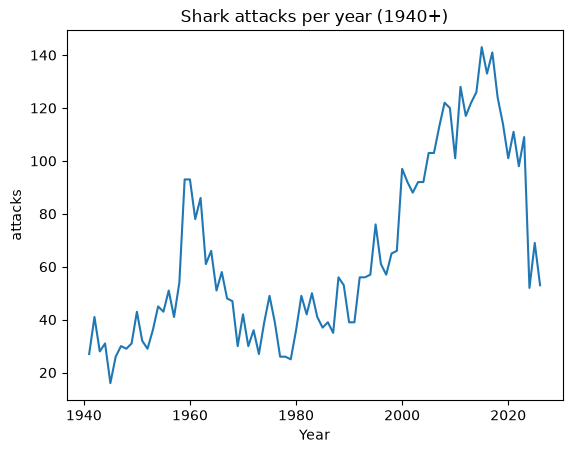

['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s' '20/30' '65' '20s' '77' '49' '!2' '73' '50s' '58' '67' '6' '41'
 '53' '68' '51' 39 51 10 13 60 '40s' 62 'teen' 8 22 32 56 'Teen' 42 50 'M'
 9 31 11 34 '!6' '!!' 47 7 71 59 53 54 75 '45 and 15' 73 52 70 4 63 44
 '28 & 22' '22, 57, 31' '60s' 67 74 '9 & 60' 'a minor' 6 3 82 '40?' 66 72
 '23' '36' '70' '18 months' '28' '33' '74' '3' '28 & 26' '5' '86'
 '18 or 20' '12 or 13' '46 & 34' '28, 23 & 30' 'Teens' 77 '36 & 26'
 '8 or 10' 84 '\xa0 ' ' ' '30 or 36' '6½' '21 & ?' '33 or 37' 'mid-30s'
 '23 & 20' 5 ' 30' '7      &    31' ' 28' '20?' "60's" '32 & 30'


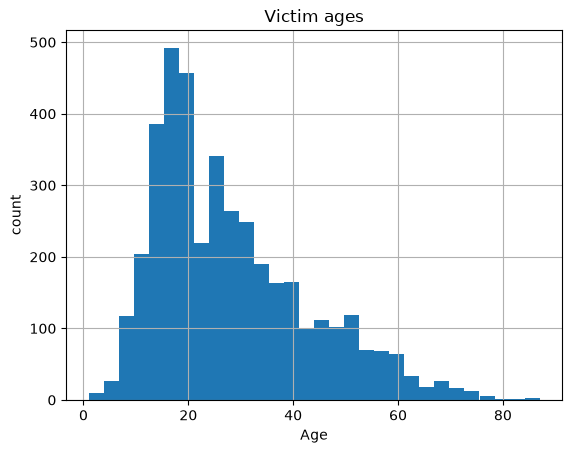

Sex
M        5594
F         803
NaN       570
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64
Sex
M      5603
F       805
NaN     578
Name: count, dtype: int64
Sex
M    0.874376
F    0.125624
Name: proportion, dtype: float64
proportion male: 0.8743757802746567
Type
Unprovoked             5150
Provoked                640
Invalid                 549
Watercraft              353
Sea Disaster            236
Questionable             27
NaN                      16
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type
Unprovoked    5152
Unknown       1192
Provoked       642
Name: count, dtype: int64
proportion unprovoked: 0.7374749498997996


In [19]:
# Shark Question 2

import pandas as pd
import matplotlib.pyplot as plt
 
# xls file, not csv, so gotta use read_excel here
sharks = pd.read_excel("./data/GSAF5.xls")
 
print(sharks.columns.tolist())
print(sharks.shape)
 
# get rid of columns that are  empty
sharks = sharks.dropna(axis=1, how='all')

# drop missing columns
min_non_null = int(0.01 * len(sharks))
sharks = sharks.dropna(axis=1, thresh=min_non_null)
 
print(sharks.shape)
print(sharks.columns.tolist())
 
sharks['Year'] = pd.to_numeric(sharks['Year'], errors='coerce')

sharks = sharks[sharks['Year'] > 0]
 
print(sharks['Year'].describe())
year_max = sharks['Year'].max()
year_min = sharks['Year'].min()
print(year_min, year_max)
 
# just want attacks since 1940 onward
recent = sharks[sharks['Year'] > 1940]
 
by_year = recent.groupby('Year').size()
print(by_year)
 
by_year.plot()
plt.xlabel("Year")
plt.ylabel("attacks")
plt.title("Shark attacks per year (1940+)")
plt.savefig("attacks_by_year.png")
plt.show()
# looks like its going up over time, more attacks recently than decades ago
 
# Age cleaning
# pull the first number out of the string
print(sharks['Age'].unique())

def age_s(value):
    if pd.isnull(value):
        return None
    digits = ""
    for char in str(value):
        if char.isdigit():
            digits = digits + char
        elif digits != "":
            break
    if digits == "":
        return None
    return int(digits)

sharks['Age'] = sharks['Age'].apply(age_s)

missing_ages = sharks['Age'].isnull().sum()
print(sharks['Age'].describe())
print("missing ages:", missing_ages)
 
sharks['Age'].hist(bins=30)
plt.xlabel("Age")
plt.ylabel("count")
plt.title("Victim ages")
plt.savefig("age_histogram.png")
plt.show()
 
# Sex / proportion male
# whitespace, lowercase m, "lli" --> clean
print(sharks['Sex'].value_counts(dropna=False))
 
sharks['Sex'] = sharks['Sex'].astype(str).str.strip().str.upper()
valid_sex = ['M', 'F']
sharks['Sex'] = sharks['Sex'].where(sharks['Sex'].isin(valid_sex))
print(sharks['Sex'].value_counts(dropna=False))
 
known_props = sharks['Sex'].value_counts(normalize=True)
male_count = (sharks['Sex'] == 'M').sum()
known_sex_count = sharks['Sex'].notna().sum()
prop_male = male_count / known_sex_count
print(known_props)
print("proportion male:", prop_male)
 
# Type cleaning --> only Provoked / Unprovoked / Unknown
# Invalid, Watercraft, Sea Disaster, Boat, Questionable etc
# none of that is really provoked/unprovoked --> becomes Unknown
print(sharks['Type'].value_counts(dropna=False))
 
cleaned_types = []
for raw_value in sharks['Type']:
    if not pd.isnull(raw_value):
        text = str(raw_value).strip().lower()
        if "unprovoked" in text:
            cleaned_types.append("Unprovoked")
        elif "provoked" in text:
            cleaned_types.append("Provoked")
        else:
            cleaned_types.append("Unknown")
    else:
        cleaned_types.append("Unknown")
 
sharks['Type'] = cleaned_types
print(sharks['Type'].value_counts(dropna=False))
 
total_rows = len(sharks)
unprovoked_count = 0
for t in sharks['Type']:
    if t == 'Unprovoked':
        unprovoked_count += 1
prop_unprovoked = unprovoked_count / total_rows
print("proportion unprovoked:", prop_unprovoked)

Overall thought process for Data Shark Revision:

I loaded the data & dropped empty columns + loaded the file with read_excel since it's an .xls file, not a csv. I dropped columns that were completely empty, plus a few more that were almost entirely empty except for one or two stray information.
Then, cleaned Year Converted Year to numeric, turning non-numeric information into missing values. I also dropped rows where Year was 0, since that's not a real year. After cleaning, Year ranges from about 5 to 2026. Filtering to attacks since 1940 and grouping by year shows attack counts are clearly higher in recent decades - dozens per year in the 1940s versus 50–100+ per year in the 2020s --> attacks are increasing over time.

For cleaning age & histogram, I revised and wrote a function that goes through any speciifc digit data findings, builds string, and then stops once it hits a non-digit out of Age. The histogram also shows most victims are most concentrated in their teens through 30s. Proportion of male victims - just M, F, or missing, then divided the male count by the number of known / non-missing values. I Recoded Type for Cleaning into just three values, ridding things like Invalid, Boat, Watercraft, and Sea Disaster into Unknown, since those aren't really about whether the shark was provoked. Some results: 87.4% of victims with a known sex are male (Approximately). 73.7% of attacks are categorized as unprovoked (approximately).

In [20]:
# Airbnb Question 1 Revision
import pandas as pd

df = pd.read_csv("./data/airbnb_hw.csv")


# raw Price column first
 
print(df['Price'].head(20))
print(type(df['Price'][0]))
 
# Price is read as a string or object, prices over 999 have commas
# Pandas is not able to convert those numbers (higher than 999)
# take commas out, convert to number

price = df['Price'].astype(str)
# make sure everything is a string
 
price = price.str.replace(",","")
# removes commas in the thousands place that causes issues

 
price = pd.to_numeric(price, errors='coerce')
# convert to float
 
df['Price'] = price
 
print(df['Price'].head(20))
print(df['Price'].describe())
 
# count of missing values
print("Missing values in Price:", df['Price'].isnull().sum())

# the max was $10,000 which is way higher than the rest of the data
# The 75th percentile is only $195, and theres a lot of round numbers
# those look like data entry errors or placeholder listings, not real prices, so I chose to bring attention to anything over $1000 --> probably an outlier

outlier_count = 0
for value in df['Price']:
    if pd.notnull(value) and value > 1000:
        outlier_count = outlier_count + 1

print("Number of likely price outliers (>$1000):", outlier_count)

df['Price_outlier'] = df['Price'] > 1000
print(df['Price_outlier'].value_counts())

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: str
<class 'str'>
0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: int64
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64
Missing values in Price: 0
Number of likely price outliers (>$1000): 135
Price_outlier
False    30343
True       135
Name: count, dtype: int64


The price was read in as a string column, not a number - pandas guessed the "object" dtype because of the commas. In addition, any price that was over 1000 did have a comma in the thousands place as a separator. pd.to_numeric messes up reading that comma, so with direct conversion there would be an error or result in a NaN result. I fixed it by taking out commas with .str.replace",","" before conversion. Afterwards, I used errors='coerce' in pd.to_numeric so that anything that still couldn't be converted to a number would become NaN. Consequently, after executing the program, the output is that there are no missing data.

The minimum and maximum prices are $10 and $10,000 respectively. On the other hand, the median is $125 and mean $164. Therefore, the difference between the two is an indication of outlier presence and positive skewness. There are also some prices ending with zeros, which are probably typos. The max was $10,000, which is way higher than the rest of the data - the 75th percentile is only $195 - and there's a lot of round numbers up there too, which look like data entry errors or placeholder listings rather than real prices. As a result, I chose to bring attention to anything over $1000, which probably are outliers.

### *Reflection on AI assistance
In your own words without generative AI.

Using AI was helpful for reviewing my code and catching places where I was losing data without realizing it. The biggest change was in how I cleaned the Shark Age column. I originally used pd.to_numeric(), which converted messy entries like "20's" or "30+" into missing values. I replaced that with a custom function that extracts the first digits, which recovered about 100 ages that were missing before. I also filtered out Year == 0 in the shark data since it is not a real year. I input a new column into the airbnb dataset code which will indicate whether the price exceeds $1,000. In one of my comments, I had pointed out that $10,000 as being the highest price, but I did not add any code for this. The other thing I have noted is that a few "Age" values which contain an exclamation mark (!) like "!2" could be interpreted as a proper age. I had known about this problem but did not add a solution to the same in my final submission because it would have affected very few rows. I did not vectorize my loops because my code was fine and re-vectorizing could introduce bugs without changing the results. Overall, AI was helpful as a reference and for double-checking my work; however, I did not end up using anything AI suggested in the first prompt because it mostly just complicated the code I already had. AI can also have difficulty with coding because it does not have access to the coding that I am doing on my end.